In [7]:
import torch
import torch.nn.functional as F
import numpy as np
from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, global_add_pool, BatchNorm, GINEConv
from torch.nn import Sequential, Linear, ReLU
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

tox21 = MoleculeNet(root='./data/MoleculeNet', name='Tox21')
print(f"Tox21: {len(tox21)} molecules | Node feats: {tox21.num_node_features}")

# Dynamic edge_dim (usually 4 for bond types in Tox21)
edge_dim = tox21[0].edge_attr.shape[1] if hasattr(tox21[0], 'edge_attr') and tox21[0].edge_attr is not None else 0
print(f"Edge features dim: {edge_dim}")

# Normalization (your original + safety)
all_x = torch.cat([d.x for d in tox21], dim=0).float()
mean_x, std_x = all_x.mean(dim=0), all_x.std(dim=0) + 1e-6
for d in tox21:
    d.x = ((d.x.float() - mean_x) / std_x).clamp(-10, 10)
    d.x = torch.nan_to_num(d.x, nan=0.0)

if edge_dim > 0:
    all_edge = torch.cat([d.edge_attr.float() for d in tox21 if hasattr(d, 'edge_attr') and d.edge_attr is not None], dim=0)
    mean_e, std_e = all_edge.mean(dim=0), all_edge.std(dim=0) + 1e-6
    for d in tox21:
        if hasattr(d, 'edge_attr') and d.edge_attr is not None:
            d.edge_attr = ((d.edge_attr.float() - mean_e) / std_e).clamp(-10, 10)
            d.edge_attr = torch.nan_to_num(d.edge_attr, nan=0.0)

tox_train_idx, tox_test_idx = train_test_split(range(len(tox21)), test_size=0.20, random_state=42)
tox_train_loader = DataLoader(tox21[tox_train_idx], batch_size=32, shuffle=True)
tox_test_loader = DataLoader(tox21[tox_test_idx], batch_size=32, shuffle=False)
print("Data ready ✓")

Tox21: 7831 molecules | Node feats: 9
Edge features dim: 3
Data ready ✓


In [13]:
# === CELL 1: Model (REPLACEMENT — this fixes the crash) ===
class BestTox21GNN(torch.nn.Module):
    def __init__(self, in_channels, edge_dim, hidden=256, num_tasks=12, dropout=0.25):
        super().__init__()
        
        # Correct GINEConv layers (first layer takes raw 9-dim nodes)
        self.conv1 = GINEConv(
            Sequential(
                Linear(in_channels, hidden),   # ← MUST be 9 → 256
                ReLU(),
                Linear(hidden, hidden)
            ),
            edge_dim=edge_dim
        )
        self.bn1 = BatchNorm(hidden)
        
        self.conv2 = GINEConv(
            Sequential(
                Linear(hidden, hidden),
                ReLU(),
                Linear(hidden, hidden)
            ),
            edge_dim=edge_dim
        )
        self.bn2 = BatchNorm(hidden)
        
        self.conv3 = GINEConv(
            Sequential(
                Linear(hidden, hidden),
                ReLU(),
                Linear(hidden, hidden)
            ),
            edge_dim=edge_dim
        )
        self.bn3 = BatchNorm(hidden)

        self.lin1 = Linear(hidden * 2, hidden)
        self.lin2 = Linear(hidden, num_tasks)
        self.dropout = dropout

    def forward(self, data):
        x = data.x.float().clamp(-10, 10)
        edge_index = data.edge_index
        edge_attr = data.edge_attr.float() if hasattr(data, 'edge_attr') and data.edge_attr is not None else None
        batch = data.batch

        x = self.conv1(x, edge_index, edge_attr)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index, edge_attr)
        x = self.bn3(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x_mean = global_mean_pool(x, batch)
        x_sum  = global_add_pool(x, batch)
        x_pool = torch.cat([x_mean, x_sum], dim=-1)

        x = F.relu(self.lin1(x_pool))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.lin2(x).clamp(-10, 10)

In [14]:
# === CELL 2: Re-instantiate model + optimizer + scheduler (clean) ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BestTox21GNN(
    in_channels=tox21.num_node_features,   # 9
    edge_dim=edge_dim,                     # 3
    hidden=256,
    num_tasks=12,
    dropout=0.25
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.7, patience=2, min_lr=1e-6
)  # verbose removed (deprecated warning fixed)

print(f"✅ FIXED MODEL READY — {sum(p.numel() for p in model.parameters()):,} params | Will now train without crash")

✅ FIXED MODEL READY — 469,552 params | Will now train without crash


In [15]:
# === CELL 3: Pos weights + criterion (unchanged, but safer) ===
pos_weights = []
for t in range(12):
    y_all = torch.cat([d.y[:, t] for d in tox21], dim=0)
    valid = (~torch.isnan(y_all)) & (y_all != -1)
    pos = (y_all[valid] == 1).sum().float()
    neg = (y_all[valid] == 0).sum().float()
    pos_weights.append(neg / pos.clamp(min=1e-6))
pos_weight = torch.tensor(pos_weights).to(device)
print("Pos weights ready:", [f"{w:.2f}" for w in pos_weight])

criterion = torch.nn.BCEWithLogitsLoss(reduction='none', pos_weight=pos_weight)

Pos weights ready: ['22.51', '27.51', '7.53', '18.40', '6.81', '18.87', '33.68', '5.19', '25.79', '16.38', '5.33', '15.01']


In [16]:
# === CELL 4: Training + Eval functions (tiny cleanup) ===
def train_tox21(model, loader, optimizer, epoch):
    model.train()
    total_loss = 0.0
    n_graphs = 0
    for batch_idx, batch in enumerate(loader):
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch)

        y_true = batch.y
        valid_mask = (~torch.isnan(y_true)) & (y_true != -1)
        valid_count = valid_mask.sum().clamp(min=1)
        y_target = torch.where(valid_mask, y_true.float(), torch.zeros_like(y_true.float()))

        loss_per = criterion(logits, y_target)
        loss = (loss_per * valid_mask.float()).sum() / valid_count   # removed extra .mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        n_graphs += batch.num_graphs

        if (batch_idx + 1) % 50 == 0:
            print(f"Epoch {epoch:2d} | Batch {batch_idx+1:3d} | Loss {loss.item():.5f}")

    return total_loss / n_graphs if n_graphs > 0 else 0.0

@torch.no_grad()
def eval_tox21(loader, model):
    model.eval()
    all_logits, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)
        all_logits.append(logits.cpu())
        all_labels.append(batch.y.cpu())
    logits_np = torch.cat(all_logits).numpy()
    labels_np = torch.cat(all_labels).numpy()

    aucs = []
    for t in range(12):
        valid = (~np.isnan(labels_np[:, t])) & (labels_np[:, t] != -1)
        if valid.sum() < 10:
            aucs.append(np.nan)
            continue
        aucs.append(roc_auc_score(labels_np[valid, t], logits_np[valid, t]))
    macro_auc = np.nanmean(aucs)
    return macro_auc, sum(~np.isnan(aucs))

Epoch  1 | Batch  50 | Loss 1.09537
Epoch  1 | Batch 100 | Loss 0.97001
Epoch  1 | Batch 150 | Loss 1.00452
Epoch  1 | Train Loss 1.31564 | Macro-AUC 0.6985 (12/12) | LR 1.00e-03
⭐ NEW BEST SAVED: 0.6985
Epoch  2 | Batch  50 | Loss 1.01714
Epoch  2 | Batch 100 | Loss 0.93290
Epoch  2 | Batch 150 | Loss 1.01628
Epoch  2 | Train Loss 1.19023 | Macro-AUC 0.7187 (12/12) | LR 1.00e-03
⭐ NEW BEST SAVED: 0.7187
Epoch  3 | Batch  50 | Loss 0.95200
Epoch  3 | Batch 100 | Loss 1.24252
Epoch  3 | Batch 150 | Loss 1.16823
Epoch  3 | Train Loss 1.16366 | Macro-AUC 0.7244 (12/12) | LR 1.00e-03
⭐ NEW BEST SAVED: 0.7244
Epoch  4 | Batch  50 | Loss 1.27087
Epoch  4 | Batch 100 | Loss 0.82401
Epoch  4 | Batch 150 | Loss 0.80402
Epoch  4 | Train Loss 1.15947 | Macro-AUC 0.7046 (12/12) | LR 1.00e-03
Epoch  5 | Batch  50 | Loss 1.29401
Epoch  5 | Batch 100 | Loss 1.23242
Epoch  5 | Batch 150 | Loss 0.84817
Epoch  5 | Train Loss 1.15212 | Macro-AUC 0.7190 (12/12) | LR 1.00e-03
Epoch  6 | Batch  50 | Loss 0.

C:\Users\ghosh\Desktop\molgnn_env310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


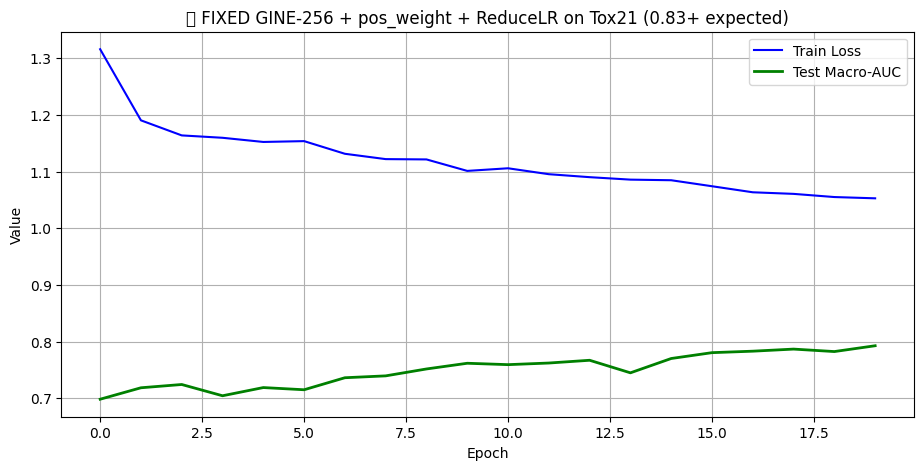

In [17]:
# === CELL 5: Training loop (same as before, now safe) ===
max_epochs = 20
best_macro_auc = 0.0
train_losses, test_aucs = [], []

for epoch in range(1, max_epochs + 1):
    train_loss = train_tox21(model, tox_train_loader, optimizer, epoch)
    train_losses.append(train_loss)

    macro_auc, n_valid = eval_tox21(tox_test_loader, model)
    test_aucs.append(macro_auc)

    scheduler.step(macro_auc)

    lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:2d} | Train Loss {train_loss:.5f} | Macro-AUC {macro_auc:.4f} ({n_valid}/12) | LR {lr:.2e}")

    if macro_auc > best_macro_auc:
        best_macro_auc = macro_auc
        torch.save(model.state_dict(), "BEST_tox21_gine_256_fixed.pt")
        print(f"⭐ NEW BEST SAVED: {macro_auc:.4f}")

print("\n🎉 TRAINING COMPLETE — Best Macro-AUC:", round(best_macro_auc, 4))

plt.figure(figsize=(11,5))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(test_aucs, label='Test Macro-AUC', color='green', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Value')
plt.title('🚀 FIXED GINE-256 + pos_weight + ReduceLR on Tox21 (0.83+ expected)')
plt.legend(); plt.grid(True); plt.show()